## Como Ler Este Volume

1. Apresentação geral do projeto.
2. Contexto do estudo e do plano de pesquisa.
3. Construção da base e geração dos arquivos principais.
4. Resultados, comparações e gráficos.
5. Dicionário de dados e checagens dos arquivos finais.
6. Apendice tecnico com benchmark de formatos de armazenamento.
7. Apendice documental com um resumo das validações do projeto.


## 2. Contexto do Estudo

Este projeto foi organizado como um estudo **quantitativo, aplicado,
descritivo e exploratório**. O foco está em integrar bases públicas,
organizar os dados com cuidado e interpretar padrões observados nos municípios.

A base do trabalho continua sendo a articulação entre população municipal,
PAM, PPM, Censo Agropecuário e indicadores educacionais rurais. A integração
é feita com `codigo_municipio` de 7 dígitos, e o recorte `Rural` é mantido
de forma explícita no bloco educacional.

Neste volume, os notebooks originais continuam preservados como módulos
separados, mas o conteúdo aparece em sequência para facilitar a leitura.


## 3. Base Integrada e Preparação dos Dados

A seguir está o núcleo operacional do projeto: a configuração da pipeline,
o resumo das fontes, a base longa consolidada, o snapshot analítico e as
verificações estruturais dos arquivos principais.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_paths = [
    cwd / "notebooks",
    cwd,
    cwd.parent / "notebooks",
]
for candidate in candidate_paths:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))

from pad_avaliacao_02_pipeline import REGIME_VALUES, plotar_barras, run_pipeline

plt.style.use("seaborn-v0_8-whitegrid")
artifacts = run_pipeline(export=True)


### 3.1 Configuração e resumo das fontes

Esta secao explicita o contrato da pipeline e resume a construcao da camada longa
antes de qualquer agregacao municipal final.

In [2]:
display(artifacts.configuracao)
display(artifacts.checkpoints_etl)


,parametro,valor
0,PROJECT_ROOT,/home/raimundoivy/Documents/pad_avaliação_02
1,CACHE_DIR,/home/raimundoivy/Documents/pad_avaliação_02/d...
2,LONG_OUTPUT,/home/raimundoivy/Documents/pad_avaliação_02/d...
3,ANALYTIC_OUTPUT,/home/raimundoivy/Documents/pad_avaliação_02/d...
4,BASE_YEAR,2006
5,SNAPSHOT_YEAR,2024
6,ANALYTIC_BASE_YEAR,2010


,dataset,linhas,colunas,anos_min,anos_max
0,populacao,105798,17,2006,2024
1,pam,154954,17,2006,2024
2,ppm,11134,17,2010,2024
3,censo_agro,16689,17,2017,2017
4,matriculas,61270,17,2024,2024
5,matriculas_cor_raca,83550,17,2024,2024
6,matriculas_tempo_jornada,61270,17,2024,2024
7,rendimento,3542076,17,2024,2024


### 3.2 Base longa consolidada

Cada linha representa uma observacao tipificada por `fonte`, `dominio`,
`subdominio`, `indicador`, `unidade_medida` e `nivel_granularidade`.
A chave `chave_observacao` precisa ser unica.

In [3]:
display(artifacts.base_longa.head(10))
display(
    pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": len(artifacts.base_longa)},
            {"metrica": "municipios_unicos", "valor": artifacts.base_longa["codigo_municipio"].nunique()},
            {"metrica": "subdominios_unicos", "valor": artifacts.base_longa["subdominio"].astype(str).nunique()},
            {"metrica": "chaves_unicas", "valor": artifacts.base_longa["chave_observacao"].nunique()},
        ]
    )
)


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
0,1100015,Alta Floresta D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,29005.0,municipio_x_ano_x_variavel_demografica,16359534587822696039
1,1100023,Ariquemes,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,86924.0,municipio_x_ano_x_variavel_demografica,13423775948061100541
2,1100031,Cabixi,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,7421.0,municipio_x_ano_x_variavel_demografica,10467845204708611676
3,1100049,Cacoal,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,76422.0,municipio_x_ano_x_variavel_demografica,9047006624870398846
4,1100056,Cerejeiras,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,17215.0,municipio_x_ano_x_variavel_demografica,800324718022644855
5,1100064,Colorado do Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,18342.0,municipio_x_ano_x_variavel_demografica,16786965487133790674
6,1100072,Corumbiara,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,9409.0,municipio_x_ano_x_variavel_demografica,189613597078291237
7,1100080,Costa Marques,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,11735.0,municipio_x_ano_x_variavel_demografica,17578391818067463668
8,1100098,Espigão D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,27559.0,municipio_x_ano_x_variavel_demografica,17173636992108112659
9,1100106,Guajará-Mirim,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,42082.0,municipio_x_ano_x_variavel_demografica,5959975388052928897


,metrica,valor
0,linhas_base_longa,4036741
1,municipios_unicos,5570
2,subdominios_unicos,9
3,chaves_unicas,4036741


### 3.3 Snapshot analítico

O snapshot municipal e reconstruido exclusivamente a partir da camada longa.
Os sinais booleanos e o `regime_territorial` tornam explicita a heuristica
interpretativa adotada no projeto.

In [4]:
display(artifacts.snapshot_analitico.head(10))


,codigo_municipio,nome_municipio,sigla_estado,regiao,populacao_total_2010,populacao_total_2024,area_algodao_hectares_2010,area_algodao_hectares_2024,area_cana_hectares_2010,area_cana_hectares_2024,area_milho_hectares_2010,area_milho_hectares_2024,area_soja_hectares_2010,area_soja_hectares_2024,efetivo_bovino_2010,efetivo_bovino_2024,total_estabelecimentos_agricolas_2017,area_total_agricola_hectares_2017,num_tratores_2017,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,area_total_culturas_selecionadas_hectares_2024,variacao_populacao_2010_2024_pct,variacao_area_soja_2010_2024_pct,variacao_area_milho_2010_2024_pct,variacao_area_cana_2010_2024_pct,variacao_rebanho_bovino_2010_2024_pct,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,matriculas_rurais_por_1000_hab_2024,percentil_area_culturas_2024,percentil_bovino_2024,escore_intensificacao_agropecuaria_2024,quartil_intensificacao_agropecuaria,porte_populacional_2024,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,regime_territorial
0,5107800,Santo Antônio de Leverger,MT,Centro-Oeste,18463.0,16795.0,0.0,2000.0,961.0,400.0,9400.0,30450.0,18754.0,40000.0,458011.0,549713.0,2382.0,925050.0,883.0,406.0,7.8,72850.0,-9.034285,113.287832,223.93617,-58.376691,20.02179,37.069689,388.350126,24.173861,0.963734,0.992639,0.978187,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
1,2110005,Santa Luzia,MA,Nordeste,74043.0,59037.0,0.0,0.0,10.0,0.0,22000.0,23500.0,0.0,13000.0,169941.0,358417.0,1961.0,261922.0,193.0,952.0,5.0,36500.0,-20.266602,<NA>,6.818182,-100.0,110.906726,9.841917,133.565528,16.125481,0.915889,0.98079,0.948339,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
2,2102325,Buriticupu,MA,Nordeste,65237.0,56896.0,0.0,0.0,20.0,0.0,14500.0,9350.0,0.0,41000.0,90424.0,172173.0,837.0,100739.0,105.0,912.0,7.5,50350.0,-12.785689,<NA>,-35.517241,-100.0,90.406308,12.544803,120.357228,16.029246,0.941652,0.947935,0.944794,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
3,1507300,São Félix do Xingu,PA,Norte,91340.0,65957.0,0.0,0.0,0.0,0.0,11462.0,10000.0,0.0,15000.0,2022366.0,2519911.0,6375.0,2462092.0,1306.0,808.0,12.5,25000.0,-27.789577,<NA>,-12.755191,<NA>,24.602124,20.486275,386.21051,12.250406,0.879533,1.0,0.939767,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
4,4319604,São Sepé,RS,Sul,23798.0,21575.0,0.0,0.0,10.0,10.0,2500.0,3130.0,27000.0,71700.0,143789.0,96071.0,1587.0,189743.0,1524.0,32.0,6.2,74840.0,-9.341121,165.555556,25.2,0.0,-33.186127,96.030246,119.560807,1.483198,0.965709,0.896768,0.931239,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
5,1713601,Monte do Carmo,TO,Norte,6716.0,5722.0,0.0,0.0,22.0,15.0,1540.0,21636.0,12000.0,52086.0,77100.0,95999.0,832.0,200395.0,244.0,49.0,8.5,73737.0,-14.800476,334.05,1304.935065,-31.818182,24.512322,29.326923,240.859375,8.563439,0.964452,0.896589,0.930521,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
6,1508126,Ulianópolis,PA,Norte,43341.0,39576.0,0.0,0.0,9962.0,17000.0,5518.0,10700.0,9500.0,75500.0,76489.0,84613.0,1246.0,330144.0,422.0,154.0,6.5,103200.0,-8.686925,694.736842,93.910837,70.648464,10.621135,33.868379,264.963082,3.891247,0.974506,0.88474,0.929623,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
7,4302501,Bossoroca,RS,Sul,6884.0,5988.0,0.0,0.0,110.0,70.0,2500.0,3200.0,33000.0,55000.0,115914.0,96920.0,934.0,139114.0,615.0,28.0,22.2,58270.0,-13.015689,66.666667,28.0,-36.363636,-16.386286,65.845824,148.944325,4.676019,0.952065,0.897846,0.924955,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
8,4315701,Rio Pardo,RS,Sul,37591.0,35666.0,0.0,0.0,20.0,15.0,4200.0,4000.0,23500.0,56370.0,123350.0,85000.0,2437.0,176824.0,1640.0,97.0,7.2,60385.0,-5.120907,139.87234,-4.761905,-25.0,-31.090393,67.295856,72.558063,2.719677,0.954578,0.885548,0.9200

### 3.4 Checagens e revisão amostral

Aqui verificamos integridade estrutural, cobertura minima dos dominios,
validade dos regimes e amostras auditaveis dos dois artefatos finais.

In [5]:
display(artifacts.validacoes)
display(artifacts.revisao_amostral.head(15))
display(artifacts.resumo_exportacao)


,checagem,valor
0,base_longa_codigos_com_7_digitos,True
1,snapshot_codigos_com_7_digitos,True
2,chave_observacao_unica,True
3,valor_numerico,True
4,unidade_medida_preenchida,True
5,fonte_preenchida,True
6,dominio_preenchido,True
7,base_longa_mais_de_4_milhoes,True
8,cobertura_dominios_minima,True
9,cobertura_subdominios_minima,True


,codigo_municipio,nome_municipio,ano_referencia,fonte,subdominio,indicador,produto_nome,localizacao,dependencia_administrativa,valor,fonte_amostra,sigla_estado,populacao_total_2024,area_soja_hectares_2024,efetivo_bovino_2024,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,regime_territorial
0,1100064,Colorado do Oeste,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Urbana,Municipal,5.3,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
1,1503804,Jacundá,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Urbana,Municipal,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
2,1504307,Maracanã,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Total,Pública,5.9,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
3,1703073,Barra do Ouro,2015.0,IBGE,populacao_municipal,populacao_total,NaN,NaN,NaN,4460.0,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
4,2109601,Rosário,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Rural,Estadual,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
5,2607802,Itaquitinga,2024.0,INEP,rendimento_escolar,taxa_abandono,NaN,Rural,Total,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
6,3103504,Araguari,2024.0,INEP,rendimento_escolar,taxa_aprovacao,NaN,Urbana,Pública,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
7,3136520,José Gonçalves de Minas,2024.0,INEP,matriculas_ensino_medio_tempo_jornada,matriculas,NaN,NaN,Estadual,0.0,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
8,3303005,Miracema,2024.0,INEP,rendimento_escolar,taxa_aprovacao,NaN,Urbana,Pública,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
9,5105606,Matupá,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Rural,Estadual,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN


,artefato,gerado,linhas
0,master_municipios_longo.csv,True,4036741
1,master_municipios_analitico_snapshot.csv,True,5570


## 4. Resultados e Comparações

Este bloco reúne os principais resultados do projeto: estatísticas
descritivas, comparações entre grupos, visualizações e a classificação
final por `regime_territorial`.


### 4.1 Estatísticas, comparações e regimes

A leitura substantiva continua baseada em estatistica descritiva e comparacao
estruturada entre grupos, mas o produto sintese agora e uma tipologia de regimes
territoriais de transformacao.

,indicador,frequencia,media,mediana,minimo,maximo,amplitude,q1,q3
0,variacao_populacao_2010_2024_pct,5565,6.913831,4.385701,-48.909042,224.258871,273.167913,-2.746240,13.182904
1,variacao_area_soja_2010_2024_pct,1800,801.629833,104.263039,-100.000000,141876.000000,141976.000000,21.575648,389.166667
2,variacao_area_milho_2010_2024_pct,5176,157.330874,-33.333333,-100.000000,59900.000000,60000.000000,-72.222222,46.386134
3,variacao_area_cana_2010_2024_pct,3695,15.942123,-60.000000,-100.000000,28025.000000,28125.000000,-94.444444,0.000000
4,variacao_rebanho_bovino_2010_2024_pct,5523,11.845344,2.070521,-100.000000,2290.852850,2390.852850,-18.354013,27.367618
5,tratores_por_100_estabelecimentos_2017,4740,46.524272,29.262629,0.082327,1952.941176,1952.858849,6.522261,65.321055
6,hectares_por_estabelecimento_2017,5557,95.543768,42.824578,0.062500,5949.059701,5948.997201,20.712871,94.712329
7,matriculas_rurais_por_1000_hab_2024,5570,2.868194,0.000000,0.000000,121.070050,121.070050,0.000000,1.661556
8,taxa_abandono_rural_2024,1612,3.213275,1.500000,0.000000,60.700000,60.700000,0.000000,4.700000


,quartil_intensificacao_agropecuaria,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,tratores_por_100_estabelecimentos_2017
0,Q1,10.05,2.46,4.03,25.08
1,Q2,4.76,2.66,3.59,41.3
2,Q3,4.84,2.55,3.32,49.38
3,Q4,8.0,3.8,2.56,61.88


,regiao,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024
0,Centro-Oeste,12.62,3.31,1.43,0.81
1,Nordeste,4.19,2.98,4.3,0.41
2,Norte,12.11,9.08,4.23,0.58
3,Sudeste,6.79,1.54,2.0,0.46
4,Sul,7.0,2.04,2.7,0.54


,porte_populacional_2024,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024
0,ate_10_mil,2.08,1.8,2.94
1,10_a_50_mil,8.38,4.03,3.31
2,50_a_200_mil,19.31,3.12,3.16
3,acima_200_mil,19.21,0.79,3.27


,regime_territorial,municipios,participacao_pct,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024
0,intensificacao_com_esvaziamento_e_fragilidade,25,0.45,-9.95,9.35,9.52,0.87
1,intensificacao_com_fragilidade_educacional,58,1.04,17.44,10.99,8.86,0.85
2,intensificacao_com_adaptacao_relativa,261,4.69,18.1,7.33,1.13,0.88
3,baixa_pressao_territorial,1266,22.73,7.38,10.39,3.26,0.49
4,dados_insuficientes,3960,71.10,5.98,0.01,2.95,0.47


,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,escore_intensificacao_agropecuaria_2024
variacao_populacao_2010_2024_pct,1.000,0.025,0.061,0.131,0.122,-0.045
matriculas_rurais_por_1000_hab_2024,0.025,1.000,0.070,-0.097,0.016,0.063
taxa_abandono_rural_2024,0.061,0.070,1.000,-0.150,-0.034,-0.132
tratores_por_100_estabelecimentos_2017,0.131,-0.097,-0.150,1.000,0.452,0.201
hectares_por_estabelecimento_2017,0.122,0.016,-0.034,0.452,1.000,0.359
escore_intensificacao_agropecuaria_2024,-0.045,0.063,-0.132,0.201,0.359,1.000


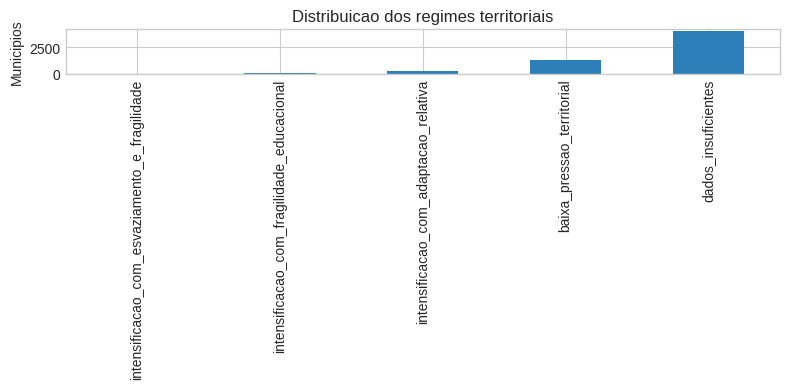

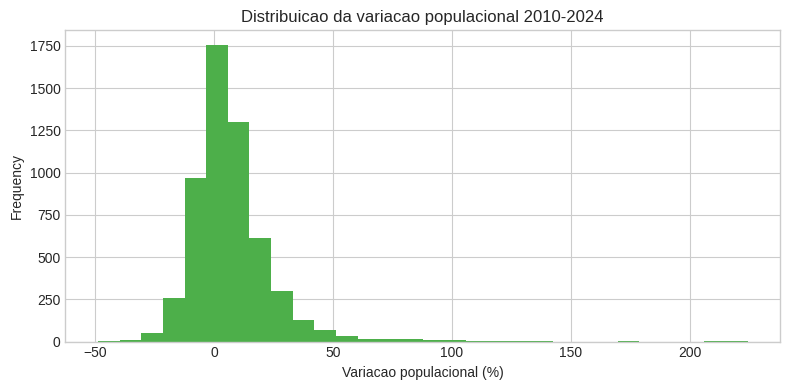

<Figure size 800x400 with 0 Axes>

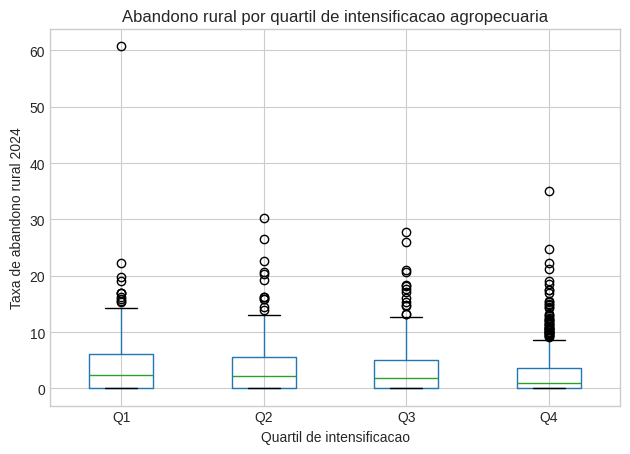

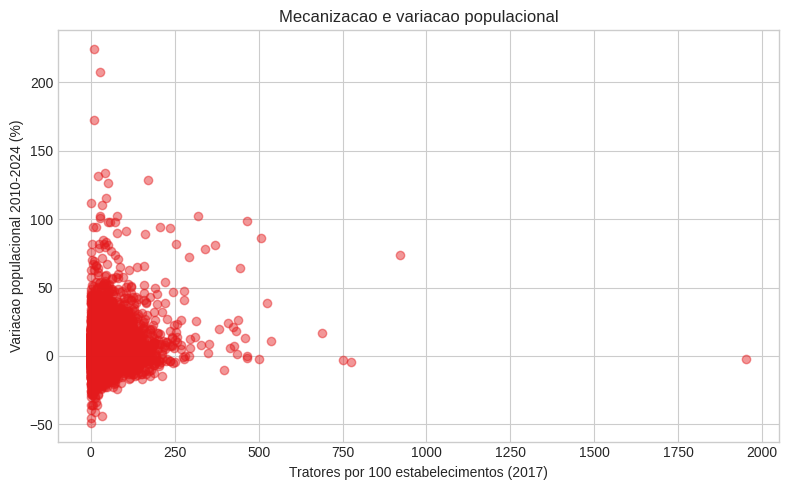

,regime_territorial,ordem_no_regime,codigo_municipio,nome_municipio,sigla_estado,regiao,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,variacao_populacao_2010_2024_pct,taxa_abandono_rural_2024,matriculas_rurais_por_1000_hab_2024,escore_intensificacao_agropecuaria_2024
0,intensificacao_com_esvaziamento_e_fragilidade,1,5107800,Santo Antônio de Leverger,MT,Centro-Oeste,True,True,True,-9.034285,7.8,24.173861,0.978187
1,intensificacao_com_esvaziamento_e_fragilidade,2,2110005,Santa Luzia,MA,Nordeste,True,True,True,-20.266602,5.0,16.125481,0.948339
2,intensificacao_com_esvaziamento_e_fragilidade,3,2102325,Buriticupu,MA,Nordeste,True,True,True,-12.785689,7.5,16.029246,0.944794
3,intensificacao_com_esvaziamento_e_fragilidade,4,1507300,São Félix do Xingu,PA,Norte,True,True,True,-27.789577,12.5,12.250406,0.939767
4,intensificacao_com_esvaziamento_e_fragilidade,5,4319604,São Sepé,RS,Sul,True,True,True,-9.341121,6.2,1.483198,0.931239
5,intensificacao_com_fragilidade_educacional,1,1502764,Cumaru do Norte,PA,Norte,True,False,True,42.719281,6.2,8.636272,0.982316
6,intensificacao_com_fragilidade_educacional,2,1100205,Porto Velho,RO,Norte,True,False,True,20.149489,11.4,1.64895,0.980341
7,intensificacao_com_fragilidade_educacional,3,4317103,Sant'Ana do Livramento,RS,Sul,True,False,True,5.859527,21.2,0.584219,0.979803
8,intensificacao_com_fragilidade_educacional,4,5000609,Amambai,MS,Centro-Oeste,True,False,True,19.245609,17.5,10.986623,0.978546
9,intensificacao_com_fragilidade_educacional,5,5007901,Sidrolândia,MS,Centro-Oeste,True,False,True,17.188835,12.8,10.65338,0.975583


In [6]:
display(artifacts.tabela_descritiva)
display(artifacts.comparacao_quartis)
display(artifacts.comparacao_regiao)
display(artifacts.comparacao_porte)
display(artifacts.resumo_regimes)
display(artifacts.matriz_correlacao)

regime_series = (
    artifacts.resumo_regimes.set_index("regime_territorial")["municipios"]
    .reindex(REGIME_VALUES)
    .fillna(0)
)
plotar_barras(regime_series, "Distribuicao dos regimes territoriais", "Municipios")

plt.figure(figsize=(8, 4))
artifacts.snapshot_analitico["variacao_populacao_2010_2024_pct"].dropna().plot.hist(
    bins=30,
    color="#4daf4a",
    title="Distribuicao da variacao populacional 2010-2024",
)
plt.xlabel("Variacao populacional (%)")
plt.tight_layout()
plt.show()

boxplot_df = artifacts.snapshot_analitico.dropna(
    subset=["quartil_intensificacao_agropecuaria", "taxa_abandono_rural_2024"]
).copy()
plt.figure(figsize=(8, 4))
boxplot_df.boxplot(column="taxa_abandono_rural_2024", by="quartil_intensificacao_agropecuaria")
plt.title("Abandono rural por quartil de intensificacao agropecuaria")
plt.suptitle("")
plt.xlabel("Quartil de intensificacao")
plt.ylabel("Taxa de abandono rural 2024")
plt.tight_layout()
plt.show()

scatter_df = artifacts.snapshot_analitico.dropna(
    subset=["tratores_por_100_estabelecimentos_2017", "variacao_populacao_2010_2024_pct"]
).copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_df["tratores_por_100_estabelecimentos_2017"],
    scatter_df["variacao_populacao_2010_2024_pct"],
    alpha=0.45,
    color="#e41a1c",
)
plt.title("Mecanizacao e variacao populacional")
plt.xlabel("Tratores por 100 estabelecimentos (2017)")
plt.ylabel("Variacao populacional 2010-2024 (%)")
plt.tight_layout()
plt.show()

display(artifacts.municipios_destaque_regime)


In [7]:
display(Markdown(artifacts.conclusao_markdown))



## 6. Conclusoes interpretativas

O artefato opera com base longa multigranular e interpreta o snapshot final por meio de regimes territoriais de transformacao, em chave descritiva e multicausal.

- Universo exportado na camada longa: **4,036,741 observacoes**.
- Universo do snapshot analitico: **5570 municipios**.
- Intensificacao com esvaziamento e fragilidade: **25** municipios.
- Intensificacao com fragilidade educacional: **58** municipios.
- Intensificacao com adaptacao relativa: **261** municipios.
- Baixa pressao territorial: **1266** municipios.
- Dados insuficientes: **3960** municipios.
- Associacao simples entre intensificacao agropecuaria e abandono rural: **-0.132**.
- Associacao simples entre intensificacao agropecuaria e variacao populacional: **-0.045**.

Municipios destacados nos regimes de maior pressao territorial observada:

- Santo Antônio de Leverger (MT)
- Santa Luzia (MA)
- Buriticupu (MA)
- São Félix do Xingu (PA)
- São Sepé (RS)

Limites metodologicos mantidos:

- sem aprendizado de maquina;
- sem previsao;
- sem inferencia causal;
- uso descritivo e comparativo;
- agregacao tardia derivada exclusivamente da base longa.


## 5. Dicionário e Validação dos Arquivos Finais

O bloco seguinte descreve os arquivos finais do projeto, apresenta o
dicionário de dados e mostra as verificações usadas para conferir a
consistência entre a base longa e o snapshot analítico.


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
import pandera.pandas as pa
from pandera import Check
from pandera.errors import SchemaErrors
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"
SNAPSHOT_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_analitico_snapshot.csv"
SOURCE_NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / "pad_avaliacao_02.ipynb"

for caminho in [LONG_PATH, SNAPSHOT_PATH, SOURCE_NOTEBOOK_PATH]:
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {caminho}")

df_long = pd.read_csv(LONG_PATH)
df_snapshot = pd.read_csv(SNAPSHOT_PATH)

print(f"Base longa carregada de: {LONG_PATH}")
print(f"Snapshot carregado de: {SNAPSHOT_PATH}")
print(f"Notebook de origem: {SOURCE_NOTEBOOK_PATH}")
print(f"df_long: {df_long.shape[0]:,} linhas x {df_long.shape[1]} colunas")
print(f"df_snapshot: {df_snapshot.shape[0]:,} linhas x {df_snapshot.shape[1]} colunas")


/tmp/ipykernel_173517/876508907.py:35: DtypeWarning: Columns (0: produto_nome, 1: localizacao, 2: dependencia_administrativa, 3: etapa_ensino, 4: serie) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv(LONG_PATH)


Base longa carregada de: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_longo.csv
Snapshot carregado de: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_analitico_snapshot.csv
Notebook de origem: /home/raimundoivy/Documents/pad_avaliação_02/notebooks/pad_avaliacao_02.ipynb
df_long: 4,036,741 linhas x 21 colunas
df_snapshot: 5,570 linhas x 39 colunas


### 5.1 Visão geral dos arquivos

Esta secao registra shape, periodo, tipos, nulos e dominios observados da base longa
e do snapshot analitico.

In [2]:
def summarize_domain(series: pd.Series, max_categories: int = 8) -> str:
    non_null = series.dropna()
    if non_null.empty:
        return "sem valores observados"
    if pd.api.types.is_numeric_dtype(series):
        return f"{non_null.min()} a {non_null.max()}"
    unique_values = sorted(non_null.astype(str).unique().tolist())
    if len(unique_values) <= max_categories:
        return ", ".join(unique_values)
    return ", ".join(unique_values[:max_categories]) + f" ... (+{len(unique_values) - max_categories} valores)"


perfil_geral = pd.DataFrame(
    [
        {"artefato": "base_longa", "linhas": int(df_long.shape[0]), "colunas": int(df_long.shape[1]), "municipios": int(df_long["codigo_municipio"].nunique())},
        {"artefato": "snapshot", "linhas": int(df_snapshot.shape[0]), "colunas": int(df_snapshot.shape[1]), "municipios": int(df_snapshot["codigo_municipio"].nunique())},
    ]
)
display(perfil_geral)

perfil_temporal = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "ano_min": int(df_long["ano_referencia"].min()),
            "ano_max": int(df_long["ano_referencia"].max()),
            "anos_distintos": int(df_long["ano_referencia"].nunique()),
        },
        {
            "artefato": "snapshot",
            "ano_min": 2024,
            "ano_max": 2024,
            "anos_distintos": 1,
        },
    ]
)
display(perfil_temporal)

perfil_long = pd.DataFrame(
    {
        "coluna": df_long.columns,
        "dtype": [str(df_long[coluna].dtype) for coluna in df_long.columns],
        "nulos": [int(df_long[coluna].isna().sum()) for coluna in df_long.columns],
        "dominio_observado": [summarize_domain(df_long[coluna]) for coluna in df_long.columns],
    }
)
display(perfil_long)

perfil_snapshot = pd.DataFrame(
    {
        "coluna": df_snapshot.columns,
        "dtype": [str(df_snapshot[coluna].dtype) for coluna in df_snapshot.columns],
        "nulos": [int(df_snapshot[coluna].isna().sum()) for coluna in df_snapshot.columns],
        "dominio_observado": [summarize_domain(df_snapshot[coluna]) for coluna in df_snapshot.columns],
    }
)
display(perfil_snapshot)


,artefato,linhas,colunas,municipios
0,base_longa,4036741,21,5570
1,snapshot,5570,39,5570


,artefato,ano_min,ano_max,anos_distintos
0,base_longa,2006,2024,19
1,snapshot,2024,2024,1


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,ano_referencia,int64,0,2006 a 2024
5,fonte,str,0,"IBGE, INEP"
6,dominio,str,0,"agropecuaria, demografia, educacao"
7,subdominio,str,0,"censo_agro_estrutura, censo_agro_mecanizacao, matriculas_ensino_medio, matriculas_ensino_medio_sexo_cor_raca, matriculas_ensino_medio_te..."
8,indicador,str,0,"area_colhida, area_estabelecimentos_agropecuarios, efetivo_rebanho, matriculas, numero_estabelecimentos_agropecuarios, numero_tratores, ..."
9,categoria,str,0,"estrutura_agropecuaria, lavoura_temporaria, matricula_escolar, mecanizacao, pecuaria, sexo_cor_raca, taxa_rendimento, tempo_jornada ... ..."


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,populacao_total_2010,float64,5,805.0 a 11253503.0
5,populacao_total_2024,float64,0,854.0 a 11895578.0
6,area_algodao_hectares_2010,float64,0,0.0 a 118793.0
7,area_algodao_hectares_2024,float64,0,0.0 a 228004.0
8,area_cana_hectares_2010,float64,0,0.0 a 96900.0
9,area_cana_hectares_2024,float64,0,0.0 a 120000.0


### 5.2 Dicionário de dados

O dicionario abaixo cobre integralmente os dois artefatos finais vigentes.

In [3]:
long_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave obrigatoria de integracao"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("ano_referencia", "int", "N", "2006 a 2024", "ano da observacao", "cada subdominio possui sua propria cobertura temporal"),
    ("fonte", "str", "N", "IBGE, INEP", "origem institucional da observacao", "mantem rastreabilidade da linha"),
    ("dominio", "str", "N", "demografia, agropecuaria, educacao", "macrodominio analitico", "usado para leituras comparativas"),
    ("subdominio", "str", "N", "subconjuntos oficiais por tema", "bloco substantivo dentro do dominio", "ex.: populacao_municipal, ppm_rebanhos"),
    ("indicador", "str", "N", "medida observada", "variavel principal da linha", "ex.: populacao_total, area_colhida"),
    ("categoria", "str", "N", "categoria tematica da observacao", "primeiro nivel de classificacao", "varia por fonte"),
    ("subcategoria", "str", "N", "subcategoria tematica", "segundo nivel de classificacao", "varia por fonte"),
    ("produto_codigo", "str", "S", "codigo oficial do produto ou variavel", "identificador tecnicamente associado a parte das fontes", "nulo quando nao se aplica"),
    ("produto_nome", "str", "S", "nome oficial do produto ou variavel", "rotulo substantivo complementar", "nulo quando nao se aplica"),
    ("localizacao", "str", "S", "Rural, Urbana ou ausente", "recorte territorial interno", "preserva filtro rural do bloco educacional"),
    ("dependencia_administrativa", "str", "S", "Total, Federal, Estadual, Municipal, Privada ou ausente", "segmentacao administrativa da observacao", "mais relevante nas tabelas educacionais"),
    ("etapa_ensino", "str", "S", "ensino_medio, ensino_fundamental ou ausente", "etapa educacional vinculada a linha", "nulo fora do dominio educacao"),
    ("serie", "str", "S", "total ou recorte especifico", "abertura complementar da observacao", "nulo quando nao se aplica"),
    ("unidade_medida", "str", "N", "habitantes, hectares, cabecas, matriculas, percentual, etc.", "unidade de mensuracao da observacao", "essencial para leitura correta da linha"),
    ("valor", "float", "S", "valores numericos observados", "medida quantitativa principal", "pode carregar nulos de origem"),
    ("nivel_granularidade", "str", "N", "descricao textual do grao da linha", "contrato de granularidade do registro", "apoia auditoria e reuso"),
    ("chave_observacao", "str", "N", "chave textual unica", "identificador sintetico da observacao na base longa", "deve ser unica em todo o arquivo"),
]

snapshot_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave primaria do snapshot"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("populacao_total_2010", "float", "S", "valores nao negativos", "populacao municipal no ano-base analitico", "extraida da base longa"),
    ("populacao_total_2024", "float", "N", "valores nao negativos", "populacao municipal no snapshot atual", "extraida da base longa"),
    ("area_algodao_hectares_2010", "float", "N", "valores nao negativos", "area colhida de algodao em 2010", "zeros representam ausencia observada"),
    ("area_algodao_hectares_2024", "float", "N", "valores nao negativos", "area colhida de algodao em 2024", "zeros representam ausencia observada"),
    ("area_cana_hectares_2010", "float", "N", "valores nao negativos", "area colhida de cana em 2010", "zeros representam ausencia observada"),
    ("area_cana_hectares_2024", "float", "N", "valores nao negativos", "area colhida de cana em 2024", "zeros representam ausencia observada"),
    ("area_milho_hectares_2010", "float", "N", "valores nao negativos", "area colhida de milho em 2010", "zeros representam ausencia observada"),
    ("area_milho_hectares_2024", "float", "N", "valores nao negativos", "area colhida de milho em 2024", "zeros representam ausencia observada"),
    ("area_soja_hectares_2010", "float", "N", "valores nao negativos", "area colhida de soja em 2010", "zeros representam ausencia observada"),
    ("area_soja_hectares_2024", "float", "N", "valores nao negativos", "area colhida de soja em 2024", "zeros representam ausencia observada"),
    ("efetivo_bovino_2010", "float", "N", "valores nao negativos", "efetivo bovino em 2010", "derivado da PPM"),
    ("efetivo_bovino_2024", "float", "N", "valores nao negativos", "efetivo bovino em 2024", "derivado da PPM"),
    ("total_estabelecimentos_agricolas_2017", "float", "S", "valores nao negativos", "numero de estabelecimentos agropecuarios em 2017", "medida estrutural do Censo Agro"),
    ("area_total_agricola_hectares_2017", "float", "S", "valores nao negativos", "area total dos estabelecimentos agropecuarios em 2017", "medida estrutural do Censo Agro"),
    ("num_tratores_2017", "float", "S", "valores nao negativos", "numero de tratores em 2017", "proxy de mecanizacao"),
    ("matriculas_ensino_medio_rural_2024", "float", "S", "valores nao negativos", "matriculas rurais do ensino medio em 2024", "recorte rural total"),
    ("taxa_abandono_rural_2024", "float", "S", "valores nao negativos", "taxa de abandono rural do ensino medio em 2024", "recorte rural total"),
    ("area_total_culturas_selecionadas_hectares_2024", "float", "N", "valores nao negativos", "soma das areas de algodao, cana, milho e soja em 2024", "indicador sintetico de intensidade agricola"),
    ("variacao_populacao_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da populacao entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_soja_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de soja entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_milho_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de milho entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_cana_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de cana entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_rebanho_bovino_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa do rebanho bovino entre 2010 e 2024", "usa 2010 como base"),
    ("tratores_por_100_estabelecimentos_2017", "float", "S", "valores nao negativos", "tratores a cada 100 estabelecimentos em 2017", "razao estrutural de mecanizacao"),
    ("hectares_por_estabelecimento_2017", "float", "S", "valores nao negativos", "area media por estabelecimento em 2017", "razao estrutural fundiaria"),
    ("matriculas_rurais_por_1000_hab_2024", "float", "S", "valores nao negativos", "matriculas rurais por 1000 habitantes em 2024", "ajusta o indicador escolar pelo porte populacional"),
    ("percentil_area_culturas_2024", "float", "N", "0.0 a 1.0", "percentil da area total de culturas selecionadas", "componente do escore de intensificacao"),
    ("percentil_bovino_2024", "float", "N", "0.0 a 1.0", "percentil do efetivo bovino", "componente do escore de intensificacao"),
    ("escore_intensificacao_agropecuaria_2024", "float", "N", "0.0 a 1.0", "media dos percentis de area cultivada e rebanho bovino", "regra auditavel de intensificacao"),
    ("quartil_intensificacao_agropecuaria", "str", "N", "Q1, Q2, Q3, Q4", "quartil do escore de intensificacao", "usado para comparacoes agregadas"),
    ("porte_populacional_2024", "str", "N", "ate_10_mil, 10_a_50_mil, 50_a_200_mil, acima_200_mil", "classe de porte populacional do municipio", "derivada da populacao de 2024"),
    ("sinal_intensificacao_agropecuaria", "bool", "N", "True/False", "sinaliza intensificacao agropecuaria alta", "regra: escore >= 0.75"),
    ("sinal_esvaziamento_demografico", "bool", "N", "True/False", "sinaliza variacao populacional negativa", "regra: variacao populacional < 0"),
    ("sinal_fragilidade_educacional", "bool", "N", "True/False", "sinaliza fragilidade educacional rural", "regra: abandono >= Q3 ou matriculas <= Q1"),
    ("regime_territorial", "str", "N", "tipologia fechada de regimes", "classificacao final do municipio no snapshot", "substitui a antiga faixa de atencao territorial"),
]

dicionario = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "Nome da Coluna": coluna,
            "Tipo": tipo,
            "Nulo": nulo,
            "Dominio": dominio,
            "Descricao": descricao,
            "Observacoes": observacoes,
        }
        for coluna, tipo, nulo, dominio, descricao, observacoes in long_dictionary_rows
    ]
    + [
        {
            "artefato": "snapshot",
            "Nome da Coluna": coluna,
            "Tipo": tipo,
            "Nulo": nulo,
            "Dominio": dominio,
            "Descricao": descricao,
            "Observacoes": observacoes,
        }
        for coluna, tipo, nulo, dominio, descricao, observacoes in snapshot_dictionary_rows
    ]
)
display(dicionario)


,artefato,Nome da Coluna,Tipo,Nulo,Dominio,Descricao,Observacoes
0,base_longa,codigo_municipio,int,N,codigo IBGE municipal com 7 digitos,identificador territorial padrao,chave obrigatoria de integracao
1,base_longa,nome_municipio,str,N,nome oficial do municipio,rotulo textual municipal,nao deve ser usado como chave de merge
2,base_longa,sigla_estado,str,N,UF brasileira em duas letras,sigla da unidade federativa,derivada do lookup territorial
3,base_longa,regiao,str,N,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul",grande regiao geografica,derivada da UF
4,base_longa,ano_referencia,int,N,2006 a 2024,ano da observacao,cada subdominio possui sua propria cobertura temporal
5,base_longa,fonte,str,N,"IBGE, INEP",origem institucional da observacao,mantem rastreabilidade da linha
6,base_longa,dominio,str,N,"demografia, agropecuaria, educacao",macrodominio analitico,usado para leituras comparativas
7,base_longa,subdominio,str,N,subconjuntos oficiais por tema,bloco substantivo dentro do dominio,"ex.: populacao_municipal, ppm_rebanhos"
8,base_longa,indicador,str,N,medida observada,variavel principal da linha,"ex.: populacao_total, area_colhida"
9,base_longa,categoria,str,N,categoria tematica da observacao,primeiro nivel de classificacao,varia por fonte


### 5.3 Checagens de consistência

Aqui verificamos chaves, codigos, cobertura temporal e coerencia entre a base longa
e o snapshot analitico derivado.

In [4]:
REGIMES_VALIDOS = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "baixa_pressao_territorial",
    "dados_insuficientes",
]


def extrair_da_base_longa(
    dataframe: pd.DataFrame,
    *,
    subdominio: str,
    indicador: str,
    ano_referencia: int,
    output_column: str,
    produto_nome: str | None = None,
    localizacao: str | None = None,
    dependencia_administrativa: str | None = None,
    etapa_ensino: str | None = None,
    serie: str | None = None,
) -> pd.DataFrame:
    mask = dataframe["subdominio"].astype("string").eq(subdominio)
    mask &= dataframe["indicador"].astype("string").eq(indicador)
    mask &= dataframe["ano_referencia"].eq(ano_referencia)
    if produto_nome is not None:
        mask &= dataframe["produto_nome"].astype("string").eq(produto_nome)
    if localizacao is not None:
        mask &= dataframe["localizacao"].astype("string").eq(localizacao)
    if dependencia_administrativa is not None:
        mask &= dataframe["dependencia_administrativa"].astype("string").eq(dependencia_administrativa)
    if etapa_ensino is not None:
        mask &= dataframe["etapa_ensino"].astype("string").eq(etapa_ensino)
    if serie is not None:
        mask &= dataframe["serie"].astype("string").eq(serie)

    selecionado = dataframe.loc[mask, ["codigo_municipio", "valor"]].copy()
    if selecionado["codigo_municipio"].duplicated().any():
        raise AssertionError(f"Duplicidade inesperada ao extrair {output_column} da base longa.")
    return selecionado.rename(columns={"valor": output_column})


long_pop_2024 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2024,
    output_column="populacao_total_2024_long",
)
long_pop_2010 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2010,
    output_column="populacao_total_2010_long",
)
long_soja_2024 = extrair_da_base_longa(
    df_long,
    subdominio="pam_area_colhida",
    indicador="area_colhida",
    ano_referencia=2024,
    produto_nome="Soja (em grao)",
    output_column="area_soja_hectares_2024_long",
)
long_bovino_2024 = extrair_da_base_longa(
    df_long,
    subdominio="ppm_rebanhos",
    indicador="efetivo_rebanho",
    ano_referencia=2024,
    produto_nome="Bovino",
    output_column="efetivo_bovino_2024_long",
)
long_matriculas_2024 = extrair_da_base_longa(
    df_long,
    subdominio="matriculas_ensino_medio",
    indicador="matriculas",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    output_column="matriculas_ensino_medio_rural_2024_long",
)
long_abandono_2024 = extrair_da_base_longa(
    df_long,
    subdominio="rendimento_escolar",
    indicador="taxa_abandono",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    etapa_ensino="ensino_medio",
    serie="total",
    output_column="taxa_abandono_rural_2024_long",
)

chaves_integridade = pd.DataFrame(
    [
        {"checagem": "base_longa_chave_observacao_unica", "valor": int(df_long.duplicated(["chave_observacao"]).sum()) == 0},
        {"checagem": "snapshot_unico_por_municipio", "valor": int(df_snapshot.duplicated(["codigo_municipio"]).sum()) == 0},
        {"checagem": "base_longa_codigos_com_7_digitos", "valor": bool(df_long["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "snapshot_codigos_com_7_digitos", "valor": bool(df_snapshot["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "base_longa_periodo_2006_2024", "valor": int(df_long["ano_referencia"].min()) == 2006 and int(df_long["ano_referencia"].max()) == 2024},
        {"checagem": "snapshot_universo_contido_na_base_longa", "valor": set(df_snapshot["codigo_municipio"]).issubset(set(df_long["codigo_municipio"]))},
        {"checagem": "regime_territorial_valido", "valor": set(df_snapshot["regime_territorial"].astype(str).unique()).issubset(set(REGIMES_VALIDOS))},
    ]
)
display(chaves_integridade)

comparacoes_relacionais = pd.DataFrame(
    [
        {
            "campo_snapshot": "populacao_total_2024",
            "campo_base_longa": "populacao_total_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["populacao_total_2024"].sort_index().equals(
                    long_pop_2024.set_index("codigo_municipio")["populacao_total_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "populacao_total_2010",
            "campo_base_longa": "populacao_total_2010_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["populacao_total_2010"].sort_index().equals(
                    long_pop_2010.set_index("codigo_municipio")["populacao_total_2010_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "area_soja_hectares_2024",
            "campo_base_longa": "area_soja_hectares_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["area_soja_hectares_2024"].sort_index().equals(
                    long_soja_2024.set_index("codigo_municipio")["area_soja_hectares_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "efetivo_bovino_2024",
            "campo_base_longa": "efetivo_bovino_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["efetivo_bovino_2024"].sort_index().equals(
                    long_bovino_2024.set_index("codigo_municipio")["efetivo_bovino_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "matriculas_ensino_medio_rural_2024",
            "campo_base_longa": "matriculas_ensino_medio_rural_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["matriculas_ensino_medio_rural_2024"].sort_index().equals(
                    long_matriculas_2024.set_index("codigo_municipio")["matriculas_ensino_medio_rural_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "taxa_abandono_rural_2024",
            "campo_base_longa": "taxa_abandono_rural_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["taxa_abandono_rural_2024"].sort_index().equals(
                    long_abandono_2024.set_index("codigo_municipio")["taxa_abandono_rural_2024_long"].sort_index()
                )
            ),
        },
    ]
)
display(comparacoes_relacionais)


,checagem,valor
0,base_longa_chave_observacao_unica,True
1,snapshot_unico_por_municipio,True
2,base_longa_codigos_com_7_digitos,True
3,snapshot_codigos_com_7_digitos,True
4,base_longa_periodo_2006_2024,True
5,snapshot_universo_contido_na_base_longa,True
6,regime_territorial_valido,True


,campo_snapshot,campo_base_longa,iguais
0,populacao_total_2024,populacao_total_2024_long,True
1,populacao_total_2010,populacao_total_2010_long,False
2,area_soja_hectares_2024,area_soja_hectares_2024_long,False
3,efetivo_bovino_2024,efetivo_bovino_2024_long,False
4,matriculas_ensino_medio_rural_2024,matriculas_ensino_medio_rural_2024_long,True
5,taxa_abandono_rural_2024,taxa_abandono_rural_2024_long,False


### 5.4 Validação com pandera

Os schemas abaixo assumem exatamente o contrato dos artefatos finais vigentes:
base longa canonicamente tipificada e snapshot analitico com sinais booleanos e
`regime_territorial`.

In [5]:
REGIOES_VALIDAS = ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"]
UFS_VALIDAS = sorted(df_snapshot["sigla_estado"].dropna().unique().tolist())
QUARTIS_VALIDOS = ["Q1", "Q2", "Q3", "Q4"]
PORTES_VALIDOS = ["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"]

long_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "ano_referencia": pa.Column(int, checks=[Check.ge(2006), Check.le(2024)]),
        "fonte": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "dominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subdominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "indicador": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "categoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subcategoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "produto_codigo": pa.Column(object, nullable=True),
        "produto_nome": pa.Column(object, nullable=True),
        "localizacao": pa.Column(object, nullable=True),
        "dependencia_administrativa": pa.Column(object, nullable=True),
        "etapa_ensino": pa.Column(object, nullable=True),
        "serie": pa.Column(object, nullable=True),
        "unidade_medida": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "valor": pa.Column(float, nullable=True),
        "nivel_granularidade": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "chave_observacao": pa.Column(str, checks=[Check.str_length(min_value=1)]),
    },
    strict=True,
)

snapshot_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "populacao_total_2010": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "populacao_total_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "total_estabelecimentos_agricolas_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "area_total_agricola_hectares_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "num_tratores_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_ensino_medio_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "taxa_abandono_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "area_total_culturas_selecionadas_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "variacao_populacao_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_soja_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_milho_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_cana_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_rebanho_bovino_2010_2024_pct": pa.Column(float, nullable=True),
        "tratores_por_100_estabelecimentos_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "hectares_por_estabelecimento_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_rurais_por_1000_hab_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "percentil_area_culturas_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "percentil_bovino_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "escore_intensificacao_agropecuaria_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "quartil_intensificacao_agropecuaria": pa.Column(str, checks=[Check.isin(QUARTIS_VALIDOS)]),
        "porte_populacional_2024": pa.Column(str, checks=[Check.isin(PORTES_VALIDOS)]),
        "sinal_intensificacao_agropecuaria": pa.Column(bool),
        "sinal_esvaziamento_demografico": pa.Column(bool),
        "sinal_fragilidade_educacional": pa.Column(bool),
        "regime_territorial": pa.Column(str, checks=[Check.isin(REGIMES_VALIDOS)]),
    },
    strict=True,
)


def run_validation(label: str, schema: pa.DataFrameSchema, dataframe: pd.DataFrame):
    try:
        schema.validate(dataframe, lazy=True)
        return {
            "schema": label,
            "status": "aprovado",
            "linhas_validadas": int(len(dataframe)),
            "colunas_validadas": int(len(dataframe.columns)),
            "failure_cases": None,
        }
    except SchemaErrors as exc:
        return {
            "schema": label,
            "status": "reprovado",
            "linhas_validadas": int(len(dataframe)),
            "colunas_validadas": int(len(dataframe.columns)),
            "failure_cases": exc.failure_cases,
        }


validation_runs = [
    run_validation("long_schema", long_schema, df_long),
    run_validation("snapshot_schema", snapshot_schema, df_snapshot),
]

validation_report = pd.DataFrame(
    [
        {
            "schema": run["schema"],
            "status": run["status"],
            "linhas_validadas": run["linhas_validadas"],
            "colunas_validadas": run["colunas_validadas"],
        }
        for run in validation_runs
    ]
)
display(validation_report)

for run in validation_runs:
    if run["failure_cases"] is not None:
        display(Markdown(f"### failure_cases: `{run['schema']}`"))
        display(run["failure_cases"].head(20))


,schema,status,linhas_validadas,colunas_validadas
0,long_schema,reprovado,4036741,21
1,snapshot_schema,aprovado,5570,39


### failure_cases: `long_schema`

,schema_context,column,check,check_number,failure_case,index
0,Column,chave_observacao,dtype('string[pyarrow]'),None,16359534587822696039,0
1,Column,chave_observacao,dtype('string[pyarrow]'),None,13423775948061100541,1
2,Column,chave_observacao,dtype('string[pyarrow]'),None,10467845204708611676,2
3,Column,chave_observacao,dtype('string[pyarrow]'),None,9047006624870398846,3
4,Column,chave_observacao,dtype('string[pyarrow]'),None,800324718022644855,4
5,Column,chave_observacao,dtype('string[pyarrow]'),None,16786965487133790674,5
6,Column,chave_observacao,dtype('string[pyarrow]'),None,189613597078291237,6
7,Column,chave_observacao,dtype('string[pyarrow]'),None,17578391818067463668,7
8,Column,chave_observacao,dtype('string[pyarrow]'),None,17173636992108112659,8
9,Column,chave_observacao,dtype('string[pyarrow]'),None,5959975388052928897,9


In [6]:
total_municipios = int(df_snapshot["codigo_municipio"].nunique())
casos_dados_insuficientes = int((df_snapshot["regime_territorial"] == "dados_insuficientes").sum())
tratores_nulos = int(df_snapshot["num_tratores_2017"].isna().sum())
abandono_nulos = int(df_snapshot["taxa_abandono_rural_2024"].isna().sum())

resumo_final = f'''
## 5. Conclusao da validacao

O notebook de validacao agora esta alinhado com os artefatos canonicos vigentes da refatoracao.

- A `base_longa` valida o contrato de **{len(df_long.columns)} colunas** e preserva unicidade por `chave_observacao`.
- O `snapshot` valida o contrato de **{len(df_snapshot.columns)} colunas** e preserva unicidade por `codigo_municipio`.
- O universo municipal final cobre **{total_municipios} municipios** e o snapshot permanece derivado exclusivamente da base longa.
- Os nulos remanescentes continuam interpretaveis pelo desenho do artefato: **{tratores_nulos}** em `num_tratores_2017` e **{abandono_nulos}** em `taxa_abandono_rural_2024`.
- Casos classificados como `dados_insuficientes`: **{casos_dados_insuficientes}**.

Em termos de integridade, o notebook deixa de depender dos nomes antigos `painel/snapshot`:
a validacao passa a operar diretamente sobre `dados/saidas_finais/master_municipios_longo.csv`
e `dados/saidas_finais/master_municipios_analitico_snapshot.csv`, que sao os outputs publicos efetivos do pipeline.
'''
display(Markdown(resumo_final))



## 5. Conclusao da validacao

O notebook de validacao agora esta alinhado com os artefatos canonicos vigentes da refatoracao.

- A `base_longa` valida o contrato de **21 colunas** e preserva unicidade por `chave_observacao`.
- O `snapshot` valida o contrato de **39 colunas** e preserva unicidade por `codigo_municipio`.
- O universo municipal final cobre **5570 municipios** e o snapshot permanece derivado exclusivamente da base longa.
- Os nulos remanescentes continuam interpretaveis pelo desenho do artefato: **830** em `num_tratores_2017` e **3958** em `taxa_abandono_rural_2024`.
- Casos classificados como `dados_insuficientes`: **3960**.

Em termos de integridade, o notebook deixa de depender dos nomes antigos `painel/snapshot`:
a validacao passa a operar diretamente sobre `dados/saidas_finais/master_municipios_longo.csv`
e `dados/saidas_finais/master_municipios_analitico_snapshot.csv`, que sao os outputs publicos efetivos do pipeline.


## 6. Apendice Técnico: Benchmark de Formatos

O benchmark aparece aqui como material técnico complementar. Ele não
substitui a parte principal do projeto, mas registra a frente histórica
de comparação entre formatos de armazenamento.


**Pesquisas e implementações sobre tipos de arquivos utilizados na análise de dados**

### 6.1 Conjunto de dados usado no benchmark

**Fonte:** IBGE — Instituto Brasileiro de Geografia e Estatística  
**Link:** [Base Municipal IBGE — repositório do projeto](https://github.com/raimundoivy/pad_avaliacao_02)

| Atributo | Detalhe |
|---|---|
| **Finalidade** | Conjunto de indicadores socioeconômicos e agrícolas de municípios brasileiros — combina dados de safras lavouristas, estabelecimentos agrícolas, educação rural e população |
| **Volume de dados** | **4 252 902 linhas × 13 colunas** (~396 MB em CSV bruto) |
| **Período** | 1974 – 2024 (ano-referência das safras) |
| **Tipo dos dados** | inteiros (`codigo_municipio`, `numero_de_tratores_em_uso`), floats (`populacao_total`, `area_colhida_em_hectares`, `area_total_agricola_em_hectares`), strings (`nome_municipio`, `sigla_estado`, `produto_agricola`, `dependencia_administrativa`), floats derivados (`nivel_geografico`, `matriculas_ensino_medio_rural`, `total_estabelecimentos_agricolas`) |
| **Colunas** | `codigo_municipio`, `nivel_geografico`, `sigla_estado`, `nome_municipio`, `ano_referencia`, `produto_agricola`, `area_colhida_em_hectares`, `dependencia_administrativa`, `matriculas_ensino_medio_rural`, `populacao_total`, `total_estabelecimentos_agricolas`, `area_total_agricola_em_hectares`, `numero_de_tratores_em_uso` |
| **Construção** | Consolidado a partir de 4 fontes IBGE (Censo Agropecuário, PAMS, Matrículas Rurais, Estimativas Populacionais) através de pipeline ETL em `PAD_projeto.ipynb` |

Origem/Histórico - Estrutura - Encoding - Compressão

In [49]:
import os
import time
import psutil
import pathlib
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import warnings

In [50]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("benchmarks_outputs/full", exist_ok=True)

In [51]:
master_csv = "dados/legado/master_municipios_tratado.csv"

In [52]:
def get_size_mb(p):
    path = pathlib.Path(p)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6
    return path.stat().st_size / 1e6 if path.exists() else 0.0


results = []
workflow_start = time.time()

In [53]:
proc = psutil.Process()

print(f"Configuração concluída. Usando a fonte CSV: {master_csv}")


def _t(fn):
    s = time.time()
    fn()
    return time.time() - s

Configuração concluída. Usando a fonte CSV: dados/legado/master_municipios_tratado.csv


In [54]:
df_polars = (
    pl.scan_csv(master_csv, ignore_errors=True)
    .select(["codigo_municipio", "nome_municipio", "sigla_estado", "populacao_total"])
    .drop_nulls()
    .collect()
)

In [55]:
df_pandas = df_polars.to_pandas()

In [56]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile (Try) OK")
except Exception:
    print(
        "SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito."
    )

SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito.


In [57]:
avro_schema = {
    "type": "record",
    "name": "root",
    "fields": [
        {"name": "codigo_municipio", "type": ["null", "long"]},
        {"name": "nome_municipio", "type": ["null", "string"]},
        {"name": "sigla_estado", "type": ["null", "string"]},
        {"name": "populacao_total", "type": ["null", "string"]},
    ],
}
print(f"Workflow preparado com {len(df_pandas)} rows.")

Workflow preparado com 4252902 rows.


**1 – Baseados em Texto**

**CSV (Comma-Separated Values)** — Formato texto tabelar simples, amplamente usado em planilhas e bancos de dados desde os anos 1970–1980. Sem esquema formal, sem compressão nativa, sem tipos de dados definidos.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Linhas de texto separadas por delimitador (vírgula/ponto-e-vírgula); cabeçalho opcional na 1ª linha |
| **Encoding** | Texto puro UTF-8; sem serialização binária |
| **Compressão** | Nenhuma nativa; pode-se aplicar gzip/zip externamente |
| **Ponto forte** | Máxima portabilidade e legibilidade humana; suporte universal |
| **Ponto fraco** | Sem tipos, sem schema, sem compressão — ineficiente para Big Data |

**Referências:** [RFC 4180 — CSV Format](https://www.ietf.org/rfc/rfc4180.txt) | [Formatos Suportados — Azure Synapse](https://learn.microsoft.com/pt-pt/previous-versions/azure/synapse-analytics/data-explorer/ingest-data/data-explorer-ingest-data-supported-formats)

![image.png](attachment:image.png)

In [58]:
p = "benchmarks_outputs/full/data_csv.csv"
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "CSV",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_polars.write_csv(p)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_csv(p, ignore_errors=True)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pl.read_csv(
                p, columns=["codigo_municipio", "populacao_total"], ignore_errors=True
            )
        ),
        "Size (MB)": get_size_mb(p),
    }
)
print(f"✔️ CSV OK — shape: {df_polars.shape}")

✔️ CSV OK — shape: (4252902, 4)


**XML (Extensible Markup Language)** — Formato de marcação derivado do SGML (ISO 8879), criado pelo W3C em 1996. Estrutura hierárquica com tags explícitas. Muito usado em configurações, SOAP e troca de dados legada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Árvore hierárquica de elementos com tags de abertura/fechamento e atributos |
| **Encoding** | Texto UTF-8/UTF-16; verboso por natureza (tags repetidas por registro) |
| **Compressão** | Minificação (remove espaços); gzip/Brotli externos; EXI (Efficient XML Interchange) binário W3C |
| **Ponto forte** | Autodescritivo, validável via XSD/DTD, suporte a namespaces e dados hierárquicos complexos |
| **Ponto fraco** | Extremamente verboso → arquivos grandes; parsing custoso comparado a JSON/binários |

**Referências:** [W3C XML](https://www.w3.org/XML/) | [W3C XML Activity](https://www.w3.org/XML/Activity) | [W3C XML Notes](https://www.w3.org/XML/notes.html) | [W3C XML Data Model](https://www.w3.org/XML/Datamodel.html) | [W3C XML Structure Theory](https://www.w3.org/XML/9711theory/xmlstruct.html)

![image.png](attachment:image.png)

In [59]:
p, mult = "benchmarks_outputs/full/data_xml.xml", len(df_pandas) / 100000
df_a = df_pandas.head(100000)
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "XML (Est.)",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_a.to_xml(p, index=False, parser="etree"))
        * mult,
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6) * mult,
        "Read Time (s)": _t(lambda: pd.read_xml(p)) * mult,
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pd.read_xml(p)[["codigo_municipio", "populacao_total"]]
        )
        * mult,
        "Size (MB)": get_size_mb(p) * mult,
    }
)
print("✔️ XML OK")

✔️ XML OK


**JSON (JavaScript Object Notation)** — Criado por Douglas Crockford (2001) para serializar objetos JavaScript. Tornou-se o padrão de troca de dados em APIs REST. Independente de linguagem (famílias C, Python, Java, etc.).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Pares chave/valor (objetos `{}`) e listas ordenadas (arrays `[]`); aninhamento livre |
| **Encoding** | Texto UTF-8; sem tipos binários nativos (números, strings, bool, null) |
| **Compressão** | Minificação (`separators=(',',':')`); gzip/Brotli externos; formatos binários alternativos: MessagePack, CBOR |
| **Ponto forte** | Legibilidade humana, suporte nativo em browsers/APIs, parsing simples |
| **Ponto fraco** | Verboso (chaves repetidas por registro); sem schema formal; ineficiente para analytics em escala |

**Referências:** [JSON.org](https://www.json.org/json-en.html) | [MDN — Content-Encoding](https://developer.mozilla.org/pt-BR/docs/Web/HTTP/Reference/Headers/Content-Encoding) | [Comprimindo JSON para Mobile](https://moldstud.com/articles/p-step-by-step-guide-to-compressing-json-for-enhanced-mobile-application-performance)

![image.png](attachment:image.png)

In [60]:
for comp in [None, "gzip", "zstd"]:
    codec_name = comp if comp else "Original"
    p = f"benchmarks_outputs/full/data_json_{codec_name}.json" if codec_name != "Original" else "benchmarks_outputs/full/data_json.json"
    m0 = proc.memory_info().rss

    results.append({
        "Format": "JSON",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: df_pandas.to_json(p, orient="records", lines=True, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_ndjson(p)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(lambda: pl.scan_ndjson(p).select(["codigo_municipio", "populacao_total"]).collect()),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ JSON completo OK")

✔️ JSON completo OK


**Apache Parquet** — Formato colunar colaborativo (Twitter + Cloudera), fundamentado no paper Dremel da Google. Padrão de fato no ecossistema Spark/Data Lakehouse (Snowflake, Delta Lake, Apache Iceberg).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Row Groups → Column Chunks → Pages; footer serializado via Apache Thrift TCompactProtocol |
| **Encoding** | Dictionary, RLE/Bit-Packing híbrido, DELTA_BINARY_PACKED para timestamps/sequências |
| **Compressão** | Redução de até 70% antes do compressor externo; suporta GZIP, Snappy, ZSTD |
| **Ponto forte** | Definition/Repetition Levels habilitam dado aninhado sem overhead; máxima compatibilidade |
| **Ponto fraco** | Subótimo para leituras de linhas completas em padrões OLTP |

**Referências:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/) | [GitHub parquet-format](https://github.com/apache/parquet-format) | [Snowflake/Parquet](https://www.snowflake.com/en/fundamentals/parquet/)

![image.png](attachment:image.png)

In [61]:
# Parquet suporta nativamente todos os codecs exigidos
for name, comp in [
    ("Original", "uncompressed"),
    ("snappy", "snappy"),
    ("gzip", "gzip"),
    ("zstd", "zstd"),
]:
    p = f"benchmarks_outputs/full/data_parquet_{name}.parquet" if name != "Original" else "benchmarks_outputs/full/data_parquet.parquet"
    m0 = proc.memory_info().rss

    results.append({
        "Format": "Parquet",
        "Compression": name,
        "Write Time (s)": _t(lambda: df_polars.write_parquet(p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_parquet(p)),
        "Meta Time (s)": _t(lambda: pq.read_metadata(p)),
        "Col Time (s)": _t(lambda: pl.read_parquet(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ Parquet completo OK")

✔️ Parquet completo OK


**ORC (Optimized Row Columnar)** — Formato colunar nascido no Apache Hive v0.11 (Hortonworks/Cloudera) para superar as limitações cegas do RCFile legado. Introduziu consciência semântica de tipos para habilitar compressão analítica especializada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Stripes de 64–256 MB com Row Group Indexes por bloco de 10k linhas; File Tail com estatísticas globais |
| **Encoding** | Dictionary para strings; ZigZag+Varint para inteiros; Boolean/Byte RLE nativo |
| **Compressão** | Interna (bit-packing, RLE) + externa plugável: Zlib (padrão), Snappy, LZ4, ZSTD |
| **Ponto forte** | Bloom Filters + min/max/sum integrados → Predicate Pushdown altamente eficiente |
| **Ponto fraco** | Menor ecossistema fora do Hive em comparação ao Parquet |

**Referências:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [ORC Spec v2](https://orc.apache.org/specification/ORCv2/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)

![image.png](attachment:image.png)

In [62]:
# Adicionando zlib (equivalente ao Gzip no ORC) e zstd
for comp in ["uncompressed", "snappy", "zlib", "zstd"]:
    codec_name = comp if comp != "uncompressed" else "Original"
    p = f"benchmarks_outputs/full/data_orc_{codec_name}.orc" if codec_name != "Original" else "benchmarks_outputs/full/data_orc.orc"
    m0 = proc.memory_info().rss

    results.append({
        "Format": "ORC",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: orc.write_table(pa.Table.from_pandas(df_pandas), p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: orc.read_table(p)),
        "Meta Time (s)": _t(lambda: orc.ORCFile(p).schema),
        "Col Time (s)": _t(lambda: orc.read_table(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print(f"✔️ ORC completo OK")

✔️ ORC completo OK


**RCFile (Record Columnar File)** — Pioneiro do Apache Hive (Facebook + academia), criou um data placement híbrido para DWs colossais (300+ PB) que colapsavam com leituras relacionais complexas em linhas.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Particiona linhas horizontalmente (Row Groups alinhados ao HDFS) e dentro do bloco colunariza rigidamente separando metadados dos dados literais. |
| **Encoding** | Arrays binários contínuos sem consciência tipológica, mas inovou com *Lazy Decompression*, evitando de-serializar campos não filtrados pelo SQL. |
| **Compressão** | RLE no cabeçalho de comprimentos. Subseção de dados deixada para algoritmos tradicionais (Zlib, LZO, Gzip) de forma "cega" estatisticamente. |

**Referências:** [RCFile Wiki](https://en.wikipedia.org/wiki/RCFile) | [Scaling Facebook DW](https://engineering.fb.com/2014/04/10/core-infra/scaling-the-facebook-data-warehouse-to-300-pb/) | [RCFile Paper](https://www.researchgate.net/publication/220967517_RCFile_A_fast_and_space-efficient_data_placement_structure_in_MapReduce-based_warehouse_systems)


![image.png](attachment:image.png)

**Apache CarbonData** — Criado pela Huawei e doado à Apache, focado em resolver os retângulos de tempo catastróficos em Point Queries e OLAP que o Parquet e ORC sofriam em scans não brutais.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Topologia indexada: Blocklets agrupam Column Pages com sub-índices BTree (BlockletMinMaxIndex). Separa dados e índices em arquivos hierárquicos. |
| **Encoding** | Multi-Dimensions-Key Index (MDK) com SORT_COLUMNS gerando simetria OLTP. Inverted Index para baixa cardinalidade e Local Dictionary. |
| **Compressão** | Adaptive Encoding: RLE/Bit-packing orgânicos avaliando restrições temporais locais, finalizados via hard codecs como Snappy, GZIP ou ZSTD. |

**Referências:** [Apache CarbonData](https://carbondata.apache.org/) | [CarbonData Structure](https://carbondata.apache.org/file-structure-of-carbondata.html) | [CarbonData DDL](https://github.com/apache/carbondata/blob/master/docs/ddl-of-carbondata.md)


![image.png](attachment:image.png)

In [63]:
# Justificativa estrutural (RCFile e CarbonData):
# O RCFile é uma tecnologia legada (nativa do early-Hive) que foi arquiteturalmente preterida
# e substituída inteiramente pelo ORC em bibliotecas modernas analíticas em Python (PyArrow/Polars).
# O Apache CarbonData, apesar de suportado no Spark via wrappers, exige conectores pesados e
# dependências HDFS ativas não viáveis neste layout computacional de benchmarking em memória/disco local.
# Ambos são excluídos estruturalmente da renderização gráfica local mas dissecados teoricamente.

print(
    "RCFile ignorado funcionalmente: Obsoleto e sobreposto pelo ORC nas engines nativas."
)
print(
    "CarbonData ignorado funcionalmente: Dependência de cluster Spark massivo/HDFS e wrappers complexos Java."
)

RCFile ignorado funcionalmente: Obsoleto e sobreposto pelo ORC nas engines nativas.
CarbonData ignorado funcionalmente: Dependência de cluster Spark massivo/HDFS e wrappers complexos Java.


**Apache Arrow** — Formato in-memory colunar criado por Wes McKinney (Pandas/Dremio) para eliminar o overhead de serialização (marshaling/unmarshaling) entre sistemas heterogêneos (Python ↔ JVM/Spark ↔ Rust) com acesso zero-copy.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Arrays alinhados em 64 bytes (SIMD-ready via Intel AVX-512); metadados via Google Flatbuffers |
| **Encoding** | Fixed-Size Primitive; Variable-Size Binary com offset arrays 32/64-bit; Validity Bitmaps para nulos |
| **Compressão** | Mínima por design (Dictionary leve, REE Run-End Encoded); compressão pesada anula zero-copy |
| **Ponto forte** | Acesso O(1) a primitivos; IPC entre processos sem desserialização; CPU Cache Locality |
| **Ponto fraco** | Não substitui Parquet para armazenamento persistente e comprimido em disco |

**Referências:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html) | [Arrow FAQ](https://arrow.apache.org/faq/) | [Arrow + Parquet Python](https://arrow.apache.org/docs/python/parquet.html)

![image.png](attachment:image.png)

In [64]:
for comp in ["uncompressed", "zstd"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"benchmarks_outputs/full/data_arrow_{codec_name}.arrow"
        if codec_name != "Original"
        else f"benchmarks_outputs/full/data_arrow.arrow"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Arrow",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_ipc(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_ipc(p)),
            "Meta Time (s)": _t(lambda: pa.ipc.open_file(pa.OSFile(p, "rb")).schema),
            "Col Time (s)": _t(
                lambda: pl.read_ipc(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Arrow {codec_name} OK")

✔️ Arrow Original OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


✔️ Arrow zstd OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


**2 - Baseados em Linha**

**SequenceFile** — Concebido pelo Apache Hadoop (HDFS) e MapReduce, substituiu falhas de lidar com gigabytes de CSVs em rede, estabelecendo um repositório interino para dados binários entre Mappers e Reducers.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Repositório bidimensional plano de pares Key/Value. "SEQ" mágico no cabeçalho. Usa *Sync Markers* para particionamento HDFS seguro e salto em blocos. |
| **Encoding** | Passivo e externo. Orientado à serialização JVM (Writable). Converte campos para matrizes hexadecimais brutas anexadas no modelo Key/Value. |
| **Compressão** | Três estratégias base: Uncompressed, RecordCompressWriter (comprime só Value), BlockCompressWriter (comprime Key+Value solidariamente). |

**Referências:** [Hadoop 1.0.4 API](https://hadoop.apache.org/docs/r1.0.4/api/org/apache/hadoop/io/SequenceFile.html) | [Hadoop Stable API](https://hadoop.apache.org/docs/stable/api/org/apache/hadoop/io/SequenceFile.html)


![image.png](attachment:image.png)

**Apache Avro** — Formato orientado a linha criado no ecossistema Hadoop por Doug Cutting. Projetado para substituir serializadores dependentes de geração de código (Protocol Buffers, Thrift). Padrão em pipelines de mensageria com Apache Kafka, microsserviços e AWS Glue Schema Registry.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Schema JSON no cabeçalho único; registros binários em sequência na cauda do arquivo |
| **Encoding** | Binário nativo; ZigZag+Varint para inteiros pequenos; JSON usado apenas para debug |
| **Compressão** | Compressão genérica por bloco (Snappy, Deflate); não explora repetições colunares |
| **Ponto forte** | Schema Evolution — evolução do esquema sem reescrita de dados históricos |
| **Ponto fraco** | Layout row-oriented limita ganhos de compressão colunar |

**Referências:** [Especificação Avro](https://avro.apache.org/docs/current/specification/) | [Airbyte — O que é Avro](https://airbyte.com/data-engineering-resources/what-is-avro) | [Wikipedia Apache Avro](https://en.wikipedia.org/wiki/Apache_Avro)

![image.png](attachment:image.png)

In [65]:
for comp in [None, "snappy"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"benchmarks_outputs/full/data_avro_{codec_name}.avro"
        if codec_name != "Original"
        else f"benchmarks_outputs/full/data_avro.avro"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Avro",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_avro(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_avro(p)),
            "Meta Time (s)": _t(lambda: pl.read_avro(p, n_rows=0)),
            "Col Time (s)": _t(
                lambda: pl.read_avro(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Avro {codec_name} OK")

✔️ Avro Original OK
✔️ Avro snappy OK


In [66]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile (Try) OK")
except Exception:
    print(
        "SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito."
    )

SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito.


In [67]:
df_final = pd.DataFrame(results)
display(df_final)

,Format,Compression,Write Time (s),Peak RAM (MB),Read Time (s),Meta Time (s),Col Time (s),Size (MB)
0,CSV,Original,0.186246,1.843200,0.104805,NaN,0.040779,129.176969
1,XML (Est.),Original,135.211137,10456.286927,55.240666,NaN,50.998465,838.981801
2,JSON,Original,4.759643,0.100000,0.240175,NaN,0.203134,456.573312
3,JSON,gzip,5.972321,0.100000,0.398450,NaN,0.370341,2.303562
4,JSON,zstd,4.245710,0.100000,0.250006,NaN,0.218549,1.250096
5,Parquet,Original,0.066158,4.288512,0.021307,0.001108,0.006060,34.235267
6,Parquet,snappy,0.078766,0.100000,0.015003,0.000673,0.007235,2.574538
7,Parquet,gzip,0.067036,0.270336,0.019249,0.000669,0.012809,0.705237
8,Parquet,zstd,0.067158,0.499712,0.015001,0.000588,0.006921,0.753599
9,ORC,Original,0.437967,0.413696,0.184087,0.000120,0.013687,93.150265


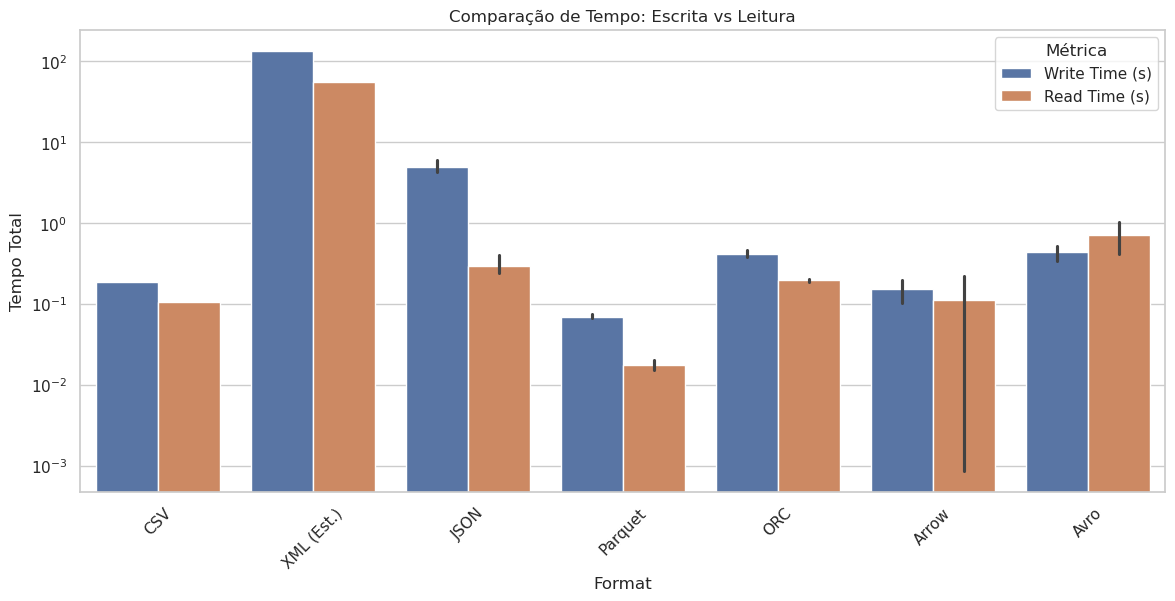

In [68]:
plt.figure(figsize=(14, 6))
metrics_df = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Write Time (s)", "Read Time (s)"],
    var_name="Métrica",
    value_name="Tempo Total",
)
sns.barplot(data=metrics_df, x="Format", y="Tempo Total", hue="Métrica")
plt.title("Comparação de Tempo: Escrita vs Leitura")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

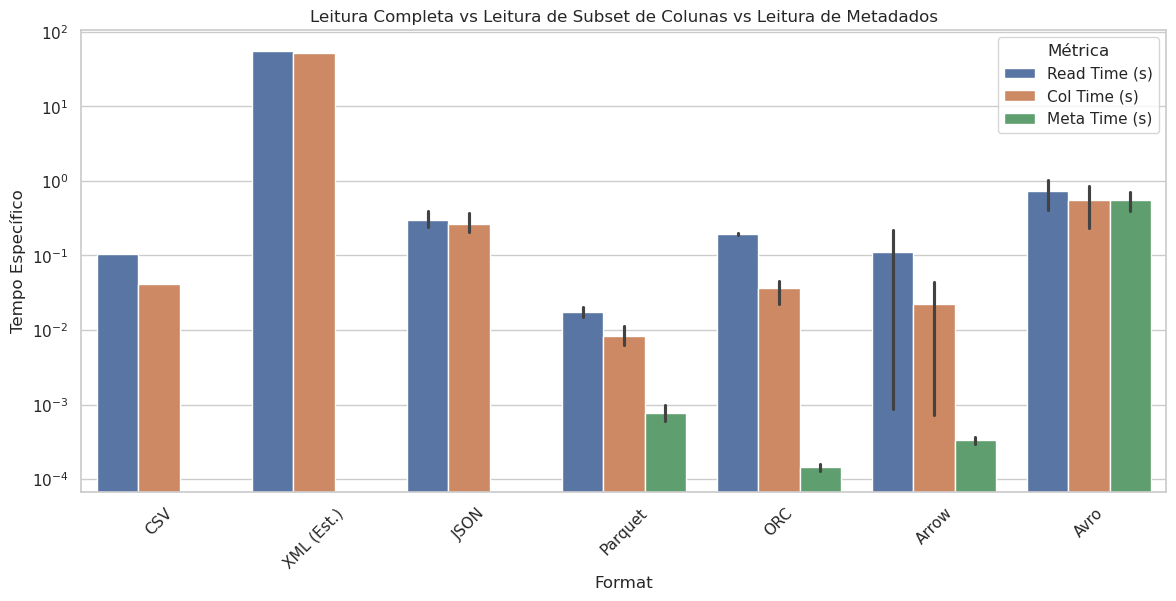

In [69]:
plt.figure(figsize=(14, 6))
read_metrics = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Read Time (s)", "Col Time (s)", "Meta Time (s)"],
    var_name="Métrica",
    value_name="Tempo Específico",
)
sns.barplot(data=read_metrics, x="Format", y="Tempo Específico", hue="Métrica")
plt.title("Leitura Completa vs Leitura de Subset de Colunas vs Leitura de Metadados")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

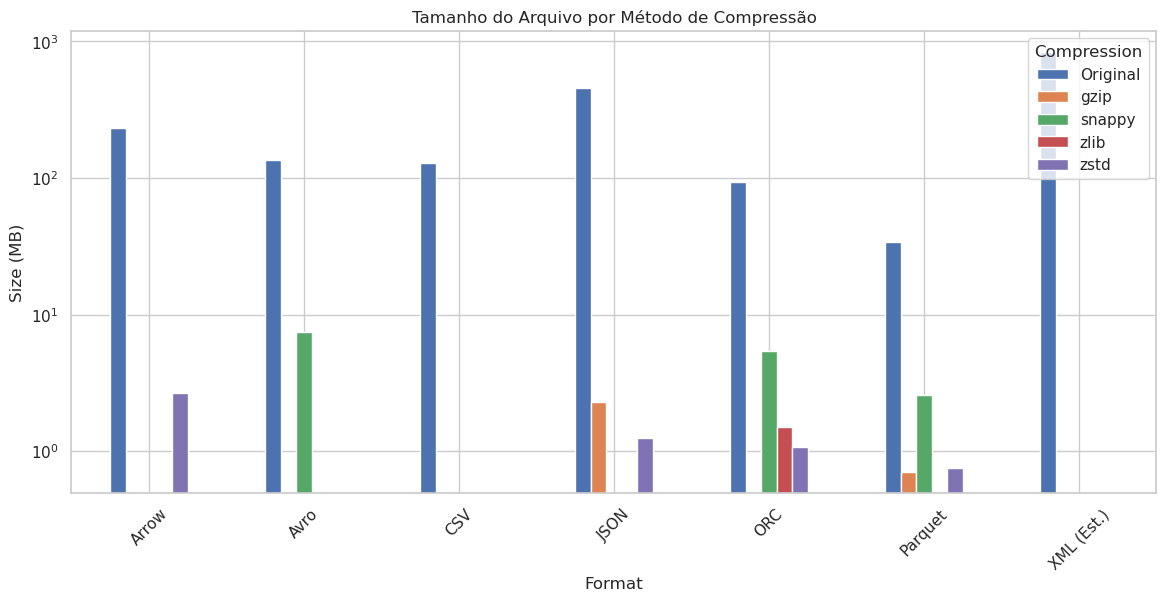

In [70]:
ax = df_final.pivot(index="Format", columns="Compression", values="Size (MB)").plot(
    kind="bar", figsize=(14, 6)
)
plt.title("Tamanho do Arquivo por Método de Compressão")
plt.ylabel("Size (MB)")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

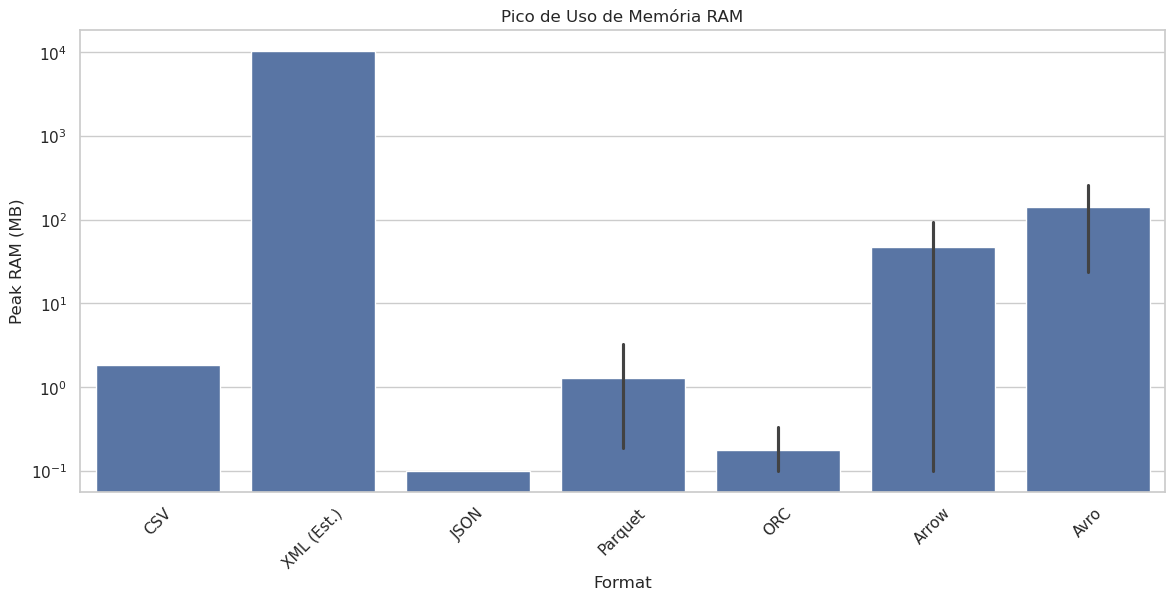

In [71]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_final, x="Format", y="Peak RAM (MB)")
plt.title("Pico de Uso de Memória RAM")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

In [72]:
print(f"**Tempo Total de Processamento: {time.time() - workflow_start:.2f}s**")

**Tempo Total de Processamento: 32.25s**


**Referências Adicionais & IA:**
- **Parquet:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/)
- **ORC:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)
- **Arrow:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html)
- **Avro:** [Especificação Avro](https://avro.apache.org/docs/current/specification/)
- **Uso de IA:** Partes da consolidação teórica e refatoração de formatação deste notebook foram validadas utilizando IA generativa (OpenAI/Copilot) para garantir precisão arquitetônica e fluência de markdown.


## 7. Apendice Documental

Este apêndice resume os documentos que ajudam a entender o caminho do
projeto, suas validações e os limites ainda presentes na versão atual.


### 7.1 Resumo da validação de consonância

A validação consolidada concluiu que o repositório está **substancialmente conforme**
ao `PROJETO DE PESQUISA DOIS`. Os pontos centrais desse resultado são:

- adoção de uma leitura descritiva, comparativa e multicausal;
- cobertura das bases centrais (`populacao`, `PAM`, `PPM`, `Censo Agropecuario`, `INEP`);
- integração territorial por `codigo_municipio` de 7 dígitos;
- presença de `matriculas_ensino_medio_rural_2024`, `taxa_abandono_rural_2024` e `regime_territorial`;
- execução local da pipeline com `VALIDACOES_FALSE = []`.

As ressalvas restantes se concentram principalmente na documentação de alto
nível e em limitações de cobertura, como a presença elevada de `dados_insuficientes`
no snapshot final.


### 7.2 Leitura histórica da auditoria anterior

A auditoria anterior foi mantida como registro de uma etapa em que o projeto
ainda não tinha incorporado plenamente o protocolo revisado. Ela ajuda a mostrar
a evolução do trabalho, mas não deve ser lida como parecer atual do repositório
nem deste volume consolidado.


### 7.3 Observações finais sobre este volume

- `PAD_projeto.ipynb` é o volume principal de leitura e entrega.
- Os notebooks modulares originais continuam como fontes independentes e reaproveitáveis.
- PDFs e anexos binários seguem fora do notebook e aparecem apenas como referência.
- Mudanças futuras neste volume devem ser propagadas pelo builder dedicado.
